# V - Transformaciones y Escalamiento de Variables


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, PowerTransformer, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from IPython.display import display, HTML

## Imputación, escalamiento y transformación de datos

Como se comprobó al inicio del proyecto mediante inspecciones rápidas de tipos, nulos y duplicados, el dataset filtrado cumple con las condiciones mínimas de calidad para continuar el preprocesamiento:

- No existen columnas de tipo texto que requieran normalización o corrección ortográfica.
- No hay columnas de fecha que requieran conversión a un formato estándar.
- No se detectaron valores faltantes (missing) en las variables seleccionadas.
- No se encontraron filas duplicadas.

Por tanto, no es necesario aplicar pasos de limpieza adicionales como imputación de missing values ni correcciones de cadenas o fechas. En adelante procederemos únicamente con las transformaciones pertinentes para la modelización: codificación de variables categóricas (si procede) y escalado/transformación de las variables numéricas según los requerimientos del modelo.

In [3]:
df_filtered = pd.read_csv("../datos/LengthOfStay_filtered.csv")
df_t = pd.read_csv("../datos/LenghtOfStay_forPartII.csv")

# Codificación binaria
df_t['gender_enc'] = df_t['gender'].map({'F': 0, 'M': 1}).fillna(-1).astype(int)

# rcount -> numérico + escalado
def rcount_to_num(x):
    if pd.isnull(x): return np.nan
    s = str(x).strip()
    if s.endswith('+'): s = s[:-1]
    try: return int(s)
    except: return np.nan

rcount = df_t['rcount'].apply(rcount_to_num).clip(0, 5).fillna(0)
df_t['rcount_scaled'] = MinMaxScaler().fit_transform(rcount.to_numpy().reshape(-1, 1))[:, 0]

# Transformations — sans fillna (vous avez dit qu'il n'y a pas de missing)
df_t['bloodureanitro_yj'] = PowerTransformer(method='yeo-johnson').fit_transform(df_t[['bloodureanitro']])[:, 0]
df_t['creatinine_z'] = StandardScaler().fit_transform(df_t[['creatinine']])[:, 0]
df_t['bmi_z'] = StandardScaler().fit_transform(df_t[['bmi']])[:, 0]
df_t['respiration_rs'] = RobustScaler().fit_transform(df_t[['respiration']])[:, 0]

df_t[['secondarydiagnosisnonicd9_yj', 'icd9_comorbidity_sum_yj']] = PowerTransformer(
    method='yeo-johnson'
).fit_transform(df_t[['secondarydiagnosisnonicd9', 'icd9_comorbidity_sum']])


# Selección final
cols = [
    'gender_enc', 'rcount_scaled', 'lengthofstay',
    'bloodureanitro_yj', 'creatinine_z', 'bmi_z', 'respiration_rs',
    'secondarydiagnosisnonicd9_yj', 'icd9_comorbidity_sum_yj'
]
df_model = df_t[cols].copy()

# Guardar
out_dir = os.path.join('..', 'datos')
os.makedirs(out_dir, exist_ok=True)
output_file = os.path.join(out_dir, 'LengthOfStay_model.csv')
df_model.to_csv(output_file, index=False)

# Vista rápida
display(df_model.describe().round(3))
display(df_model.head())


,gender_enc,rcount_scaled,lengthofstay,bloodureanitro_yj,creatinine_z,bmi_z,respiration_rs,secondarydiagnosisnonicd9_yj,icd9_comorbidity_sum_yj
count,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000
mean,0.424,0.224,4.001,-0.000,-0.000,-0.000,-0.006,-0.000,0.000
std,0.494,0.309,2.360,1.000,1.000,1.000,0.568,1.000,1.000
min,0.000,0.000,1.000,-6.772,-4.392,-3.899,-6.300,-1.937,-0.845
25%,0.000,0.000,2.000,-0.224,-0.672,-0.674,0.000,-0.425,-0.845
50%,0.000,0.000,4.000,-0.019,-0.003,0.001,0.000,-0.425,-0.845
75%,1.000,0.400,6.000,0.334,0.677,0.674,0.000,0.795,0.874
max,1.000,1.000,17.000,5.316,4.673,4.556,3.500,2.166,1.872


,gender_enc,rcount_scaled,lengthofstay,bloodureanitro_yj,creatinine_z,bmi_z,respiration_rs,secondarydiagnosisnonicd9_yj,icd9_comorbidity_sum_yj
0,0,0.0,3,-0.018810,1.454965,0.312741,0.0,1.135466,-0.845355
1,0,1.0,7,-1.012615,-0.779911,-0.671360,0.0,-0.424776,-0.845355
2,0,0.2,3,-0.018810,-0.167779,-0.480071,0.0,0.320451,-0.845355
3,0,0.0,1,-0.018810,-0.961187,-0.921644,0.0,-0.424776,-0.845355
4,0,0.0,4,-0.118648,0.716587,0.226159,-0.9,0.320451,1.345892


En esta sección se aplican distintas transformaciones a las variables del conjunto de datos con el objetivo de **mejorar la normalidad**, **reducir la influencia de valores extremos** y **homogeneizar las escalas** antes del modelado.

### Criterios generales
Cada variable fue tratada según su naturaleza estadística (distribución, rango, tipo y presencia de outliers):

| Variable | Tipo / Naturaleza | Transformación aplicada | Justificación |
|-----------|------------------|--------------------------|----------------|
| `gender` | Categórica binaria | Codificación (F=0, M=1) | Conversión directa para modelos numéricos. |
| `rcount` | Categórica ordinal (0–5+) | **MinMaxScaler (0–1)** | Mantiene la relación ordinal y escala uniforme. |
| `bloodureanitro` | Continua con sesgo positivo | **Yeo–Johnson** | Corrige la asimetría sin requerir valores estrictamente positivos. |
| `creatinine` | Continua aproximadamente normal | **Estandarización (Z-score)** | Centra y escala, facilitando la comparación entre individuos. |
| `bmi` | Continua (normal en la mayoría de casos) | **Estandarización (Z-score)** | Escalado clásico, mantiene la interpretación en desviaciones típicas. |
| `respiration` | Continua con outliers posibles | **RobustScaler** | Reduce el impacto de valores atípicos en las colas. |
| `secondarydiagnosisnonicd9` | Discreta positiva | **Yeo–Johnson** | Normaliza conteos sin perder estructura. |
| `icd9_comorbidity_sum` | Discreta positiva | **Yeo–Johnson** | Mejora la simetría y suaviza valores altos. |
| `lengthofstay` | Variable objetivo | Sin transformación | Se mantiene tal cual para conservar la interpretación directa. |

### Justificación técnica

- **Yeo–Johnson**: Permite transformar variables con valores cero o negativos, a diferencia de Box–Cox, lo que la hace más flexible para datos clínicos.
- **Z-score (StandardScaler)**: Adecuado para variables con distribución aproximadamente normal.
- **RobustScaler**: Usa la mediana y el rango intercuartílico, ideal cuando existen valores extremos.
- **MinMaxScaler**: Escala dentro de un rango fijo (0–1), útil para variables discretas con límite superior conocido.

### Resultado esperado
Estas transformaciones buscan:
- Reducir la asimetría y mejorar la aproximación a la normalidad.  
- Evitar que variables con grandes magnitudes dominen el modelo.  


Finalmente, el conjunto transformado se guarda como  
`../datos/LengthOfStay_model.csv`, listo para su uso en el modelado predictivo.


## Estrategia de balanceo de datos: Submuestreo (Undersampling)

Al analizar la variable **_Length of Stay_**, se observa un fuerte desbalance en la distribución de las duraciones de estancia: la mayoría de los pacientes presentan valores entre **0 y 3 días**, como se puede ver en el histograma.  
Este desbalance puede afectar el rendimiento de los modelos predictivos, ya que estos tienden a favorecer la clase mayoritaria, reduciendo la capacidad de generalización.

Para abordar este problema, se decidió aplicar un **método de submuestreo (undersampling)**, que consiste en **reducir el número de instancias de las clases mayoritarias** con el fin de equilibrar el conjunto de datos.  


### Técnica utilizada: Random Undersampling (RUS)

Entre las distintas variantes de submuestreo (como **Tomek Links**, **Edited Nearest Neighbors (ENN)** o **Cluster Centroids**), se optó por aplicar la técnica de **Random Undersampling (RUS)**.

#### Descripción:
El método **RUS** elimina aleatoriamente muestras de la clase mayoritaria para equilibrar las proporciones entre clases 

#### Justificación de la elección:
Probé diferentes técnicas de submuestreo, pero los resultados obtenidos no lograban reducir suficientemente el desbalance (seguían existiendo grandes diferencias entre las clases).  
Por este motivo, opté por aplicar un **Random Undersampling controlado**, **forzando un máximo de 100 muestras por cada valor de _Length of Stay_**.  
Para las estancias más largas (que son menos frecuentes), se mantuvo un número menor de observaciones, de manera que el conjunto total quedara más equilibrado.

#### Ventajas:
- Permite obtener un conjunto de datos más balanceado, lo que facilita el análisis y la comparación entre clases.  
- Mejora la claridad de los resultados frente a trabajar con más de **100 000 muestras** desbalanceadas.  
- Reduce el tiempo de entrenamiento y simplifica la interpretación de los modelos.

#### Desventaja:
- Se puede perder cierta información relevante al eliminar instancias de la clase mayoritaria, pero se considera un compromiso razonable para lograr un análisis más claro y equilibrado.


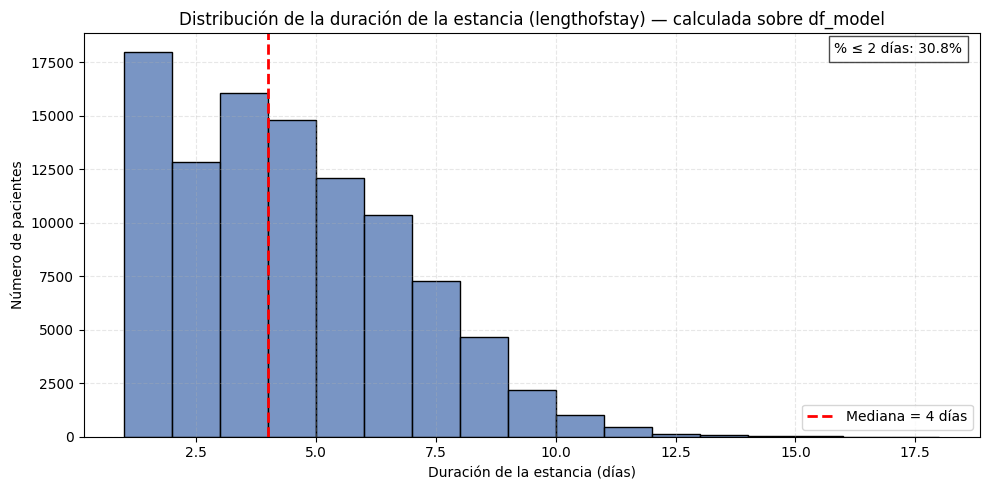

In [4]:
los = df_model['lengthofstay'].dropna().astype(int)
bins = range(los.min(), los.max() + 2)

plt.figure(figsize=(10,5))
sns.histplot(los, bins=bins, color='#4C72B0', edgecolor='k', stat='count')
median = int(np.median(los))
pct_short = (los <= 2).mean() * 100

plt.axvline(median, color='red', linestyle='--', linewidth=2, label=f'Mediana = {median} días')
plt.text(0.98, 0.95, f'% ≤ 2 días: {pct_short:.1f}%', transform=plt.gca().transAxes,
         horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.7))

plt.title("Distribución de la duración de la estancia (lengthofstay) — calculada sobre df_model")
plt.xlabel("Duración de la estancia (días)")
plt.ylabel("Número de pacientes")
plt.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split # <--- Faltaba esto
from sklearn.preprocessing import LabelEncoder

# --- Asumiendo que df_model ya está cargado ---
# Si no, descomenta la línea de abajo:
# df_model = pd.read_csv('../datos/LengthOfStay_model.csv')

# 1. Crear la variable objetivo (Target)
def categorizar_los(los):
    if los <= 2: return 'corto'   # 0-2 días
    elif los <= 7: return 'medio' # 3-7 días
    else: return 'largo'          # 8+ días

df_model['LOS_grupo'] = df_model['lengthofstay'].apply(categorizar_los)

# 2. Separar X e y
# ¡IMPORTANTE!: Eliminar 'lengthofstay' para evitar "data leakage"
cols_drop = ['lengthofstay', 'LOS_grupo', 'los_group']
X = df_model.drop(columns=[c for c in cols_drop if c in df_model.columns])
y = df_model['LOS_grupo']

# 3. Codificar etiquetas
le = LabelEncoder()
le.fit(['corto', 'medio', 'largo']) 
y_enc = le.transform(y)

# 4. Split Train/Test estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, stratify=y_enc, test_size=0.3, random_state=42
)

print(f"Clases: {le.classes_}")
print(f"Dimensiones Train: {X_train.shape}, Test: {X_test.shape}")

Clases: ['corto' 'largo' 'medio']
Dimensiones Train: (70000, 8), Test: (30000, 8)


Iniciando entrenamiento comparativo...
 -> Modelo 'Baseline (Ninguno)' terminado. F1-Macro: 0.758
 -> Modelo 'Class Weight' terminado. F1-Macro: 0.739
 -> Modelo 'SMOTE (Oversampling)' terminado. F1-Macro: 0.742
 -> Modelo 'UnderSampling' terminado. F1-Macro: 0.739
Orden visual forzado: ['corto', 'medio', 'largo']
Índices correspondientes: [np.int64(0), np.int64(2), np.int64(1)]


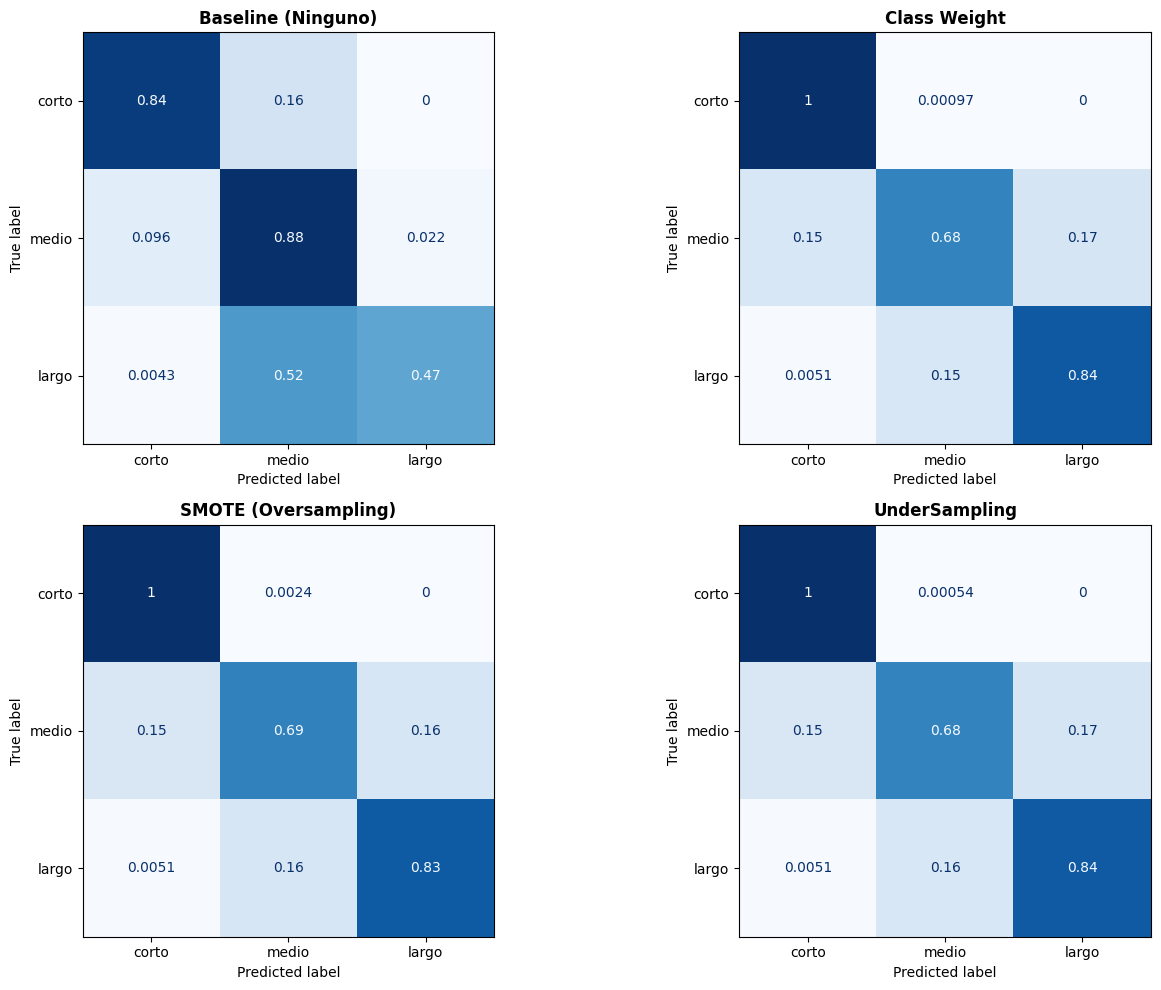

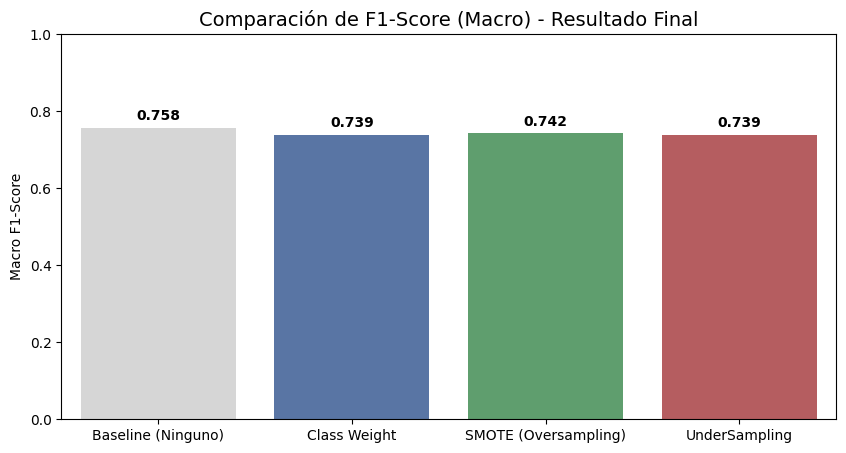

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- IMPORTS NECESARIOS (Coupables de l'erreur) ---
from sklearn.linear_model import LogisticRegression  # <--- Faltaba esto
from sklearn.metrics import f1_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# --- CONFIGURACIÓN ---
strategies = [
    ("Baseline (Ninguno)", None, LogisticRegression(max_iter=3000, random_state=42)),
    ("Class Weight", None, LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)),
    ("SMOTE (Oversampling)", SMOTE(random_state=42), LogisticRegression(max_iter=3000, random_state=42)),
    ("UnderSampling", RandomUnderSampler(random_state=42), LogisticRegression(max_iter=3000, random_state=42))
]

results = {}
preds = {}

print("Iniciando entrenamiento comparativo...")

# --- BUCLE DE ENTRENAMIENTO ---
for name, sampler, model in strategies:
    # A. Resampling (Solo en Train)
    if sampler:
        X_res, y_res = sampler.fit_resample(X_train, y_train)
    else:
        X_res, y_res = X_train, y_train
        
    # B. Ajuste del modelo
    model.fit(X_res, y_res)
    
    # C. Predicción
    y_pred = model.predict(X_test)
    preds[name] = y_pred
    
    # D. Guardar métricas
    f1 = f1_score(y_test, y_pred, average='macro')
    results[name] = f1
    print(f" -> Modelo '{name}' terminado. F1-Macro: {f1:.3f}")

# --- VISUALIZACIÓN CORREGIDA (Sin Warning) ---

# 1. Definir el orden deseado explícitamente
desired_order = ['corto', 'medio', 'largo']

# Buscamos qué índice numérico tiene cada clase en el encoder actual
# (Esto corrige el problema de que 'largo' salga antes que 'medio' por orden alfabético)
labels_indices = [np.where(le.classes_ == label)[0][0] for label in desired_order]

print(f"Orden visual forzado: {desired_order}")
print(f"Índices correspondientes: {labels_indices}")

# Preparamos los datos
nombres = list(results.keys())
valores = list(results.values())

# 2. Matrices de Confusión
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, _, _) in enumerate(strategies):
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        preds[name], 
        # AQUÍ ESTÁ EL TRUCO:
        labels=labels_indices,       # Le decimos en qué orden leer los números
        display_labels=desired_order, # Le decimos qué nombres poner en ese orden
        ax=axes[i], 
        cmap='Blues', 
        normalize='true', 
        colorbar=False
    )
    axes[i].set_title(f"{name}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Gráfico de Barras
plt.figure(figsize=(10, 5))
colors = ['#d6d6d6', '#4C72B0', '#55A868', '#C44E52']

sns.barplot(x=nombres, y=valores, hue=nombres, legend=False, palette=colors)

plt.title('Comparación de F1-Score (Macro) - Resultado Final', fontsize=14)
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1.0) 

for i, v in enumerate(valores):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

plt.show()

## Análisis e interpretación de las estrategias de muestreo

Al analizar los resultados obtenidos tras aplicar las diferentes estrategias de balanceo, observamos una paradoja interesante: aunque la **Baseline** (modelo sin procesar) presenta el F1-Score global más alto (**0.758**), un análisis más profundo revela deficiencias críticas que las técnicas de balanceo logran corregir.

### 1. El engaño de la métrica global (Baseline)
El modelo original parece funcionar bien, pero su matriz de confusión muestra un **sesgo severo**:
* Ignora gran parte de la clase minoritaria **"Largo"**, identificando correctamente solo el **47%** de los casos reales.
* Confunde sistemáticamente a los pacientes de larga estancia con los de estancia media (**52% de error**). Esto lo hace poco útil para la gestión hospitalaria, donde anticipar ocupaciones largas es crucial.

### 2. Mejora significativa en la detección de casos críticos
Al introducir técnicas de balanceo (**Class Weight, SMOTE, Undersampling**), se observa una **mejora drástica en la sensibilidad** del modelo:

* **Recuperación de la clase "Largo":** El modelo pasa de detectar el 47% a detectar aproximadamente el **84%** de los pacientes de larga estancia. Esto aporta una **mayor coherencia y utilidad** al modelo predictivo.
* **Perfeccionamiento en "Corto":** La clasificación de estancias cortas se vuelve casi perfecta (Recall ~1.0), eliminando la confusión con estancias más largas.

### 3. El costo del balanceo (Trade-off)
Esta mejora en los extremos tiene un precio: la precisión en la clase **"Medio"** disminuye (de 0.88 a ~0.68). Al forzar al algoritmo a prestar atención a las clases minoritarias, se genera cierta confusión en la zona intermedia de la distribución.

### Conclusión Final
A pesar de tener un F1-Score macro ligeramente inferior (**0.739**), los modelos balanceados (especialmente **Class Weight** o **SMOTE**) son superiores desde el punto de vista del negocio.

Estos modelos ofrecen una **interpretación más robusta y segura**, garantizando que los pacientes de larga estancia sean detectados a tiempo. Por tanto, se priorizará el uso de **Class Weight** por su simplicidad y eficacia comparable a SMOTE, asegurando una predicción más equilibrada y útil para la toma de decisiones clínicas.